# Feature Engineering

Builds a pseudo-user ID (UID) from card/address/email fields, then uses it
to derive per-user behavioral aggregations, plus frequency and cyclical
time encodings. The UID itself is dropped before saving -- it generalizes
poorly to unseen clients and is only useful for computing aggregates.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Load the datasets produced by Notebook 02
# (merged, downcasted, NaN-indicators already added, PCA applied to V-features)
print('Loading datasets...')
split_train = pd.read_parquet('../data/split_train_eda.parquet')
split_test  = pd.read_parquet('../data/split_test_eda.parquet')

print(f'split_train: {split_train.shape[0]:,} rows x {split_train.shape[1]} columns')
print(f'split_test:  {split_test.shape[0]:,} rows x {split_test.shape[1]} columns')
print(f'Fraud rate (train): {split_train["isFraud"].mean():.2%}')
print(f'Fraud rate (test):  {split_test["isFraud"].mean():.2%}')

Loading datasets...
split_train: 472,432 rows x 354 columns
split_test:  118,108 rows x 354 columns
Fraud rate (train): 3.51%
Fraud rate (test):  3.44%


## UID Reconstruction

No stable user identifier exists in the dataset. `D1` encodes days since a
card's first transaction, so `TransactionDay - D1` reconstructs the card's
issue date -- a time-invariant anchor. Combined with `card1`, `addr1`, and
`P_emaildomain`, this forms a pseudo-UID for the same physical user across
months.


In [2]:
for df in [split_train, split_test]:
    df['TransactionDay'] = (df['TransactionDT'] // 86400).astype(np.int16)
    # D1 might have NaNs — fill with 0 so the UID is still valid (just less precise)
    df['D1_filled'] = df['D1'].fillna(0).astype(np.int16)
    df['D1n'] = (df['TransactionDay'] - df['D1_filled']).astype(np.int16)

print(f'TransactionDay range (train): {split_train["TransactionDay"].min()} - {split_train["TransactionDay"].max()}')
print(f'D1n range (train): {split_train["D1n"].min()} - {split_train["D1n"].max()}')
print(f'D1 NaN rate (train): {split_train["D1"].isnull().mean():.1%}')

TransactionDay range (train): 1 - 141
D1n range (train): -633 - 141
D1 NaN rate (train): 0.2%


In [3]:
for df in [split_train, split_test]:
    df['UID'] = (df['card1'].astype(str) + '_' +
                 df['addr1'].fillna(-1).astype(int).astype(str) + '_' +
                 df['D1n'].astype(str) + '_' +
                 df['P_emaildomain'].fillna('unknown').astype(str))

n_unique_uids_train  = split_train['UID'].nunique()
n_transactions_train = len(split_train)
avg_per_uid_train    = n_transactions_train / n_unique_uids_train

n_unique_uids_test  = split_test['UID'].nunique()
n_transactions_test = len(split_test)

# How many test-period UIDs were never seen during training?
unseen_uids = set(split_test['UID']) - set(split_train['UID'])
pct_unseen  = len(unseen_uids) / n_unique_uids_test

print(f'Unique UIDs (train):       {n_unique_uids_train:,}')
print(f'Total transactions (train): {n_transactions_train:,}')
print(f'Avg transactions / UID (train): {avg_per_uid_train:.1f}')
print(f'Unique UIDs (test):        {n_unique_uids_test:,}')
print(f'UIDs in test never seen in train: {len(unseen_uids):,} ({pct_unseen:.1%})')

Unique UIDs (train):       229,028
Total transactions (train): 472,432
Avg transactions / UID (train): 2.1
Unique UIDs (test):        66,235
UIDs in test never seen in train: 44,665 (67.4%)


In [11]:
# Clean slate: remove any uid_* feature columns from previous (broken) runs
cols_to_drop = ['uid_amt_mean', 'uid_amt_std', 'uid_count', 'uid_amt_zscore', 'uid_freq_per_day']
split_train = split_train.drop(columns=[c for c in cols_to_drop if c in split_train.columns])
split_test  = split_test.drop(columns=[c for c in cols_to_drop if c in split_test.columns])

print('Remaining uid_* columns in split_train:', [c for c in split_train.columns if 'uid_' in c])
print('Remaining uid_* columns in split_test:', [c for c in split_test.columns if 'uid_' in c])

Remaining uid_* columns in split_train: []
Remaining uid_* columns in split_test: []


## Aggregation Features

Per-UID statistics turn an absolute transaction amount into a relative
signal: is this transaction unusual *for this user*, regardless of its
absolute size.


In [12]:
print('Computing UID aggregation features (learned from split_train only)...')

uid_stats = split_train.groupby('UID')['TransactionAmt'].agg(
    uid_amt_mean='mean',
    uid_amt_std='std',
    uid_count='count'
).reset_index()

global_amt_mean = split_train['TransactionAmt'].mean()
global_amt_std  = split_train['TransactionAmt'].std()

print(f"Train UIDs with exactly 1 transaction (std is NaN by definition): {(uid_stats['uid_count'] == 1).sum():,} / {len(uid_stats):,}")

for df_name, df in [('split_train', split_train), ('split_test', split_test)]:
    df_merged = df.merge(uid_stats, on='UID', how='left')

    df_merged['uid_amt_mean'] = df_merged['uid_amt_mean'].fillna(global_amt_mean).astype(np.float32)
    df_merged['uid_amt_std']  = df_merged['uid_amt_std'].fillna(global_amt_std).astype(np.float32)
    df_merged['uid_count']    = df_merged['uid_count'].fillna(0).astype(np.int16)

    raw_zscore = (
        (df_merged['TransactionAmt'] - df_merged['uid_amt_mean'])
        / df_merged['uid_amt_std'].replace(0, 1)
    )
    df_merged['uid_amt_zscore'] = raw_zscore.clip(-10, 10).astype(np.float32)

    if df_name == 'split_train':
        split_train = df_merged
    else:
        split_test = df_merged

uid_daily_stats = (split_train.groupby(['UID', 'TransactionDay'])['TransactionAmt']
                    .count().rename('uid_freq_per_day').reset_index())

for df_name, df in [('split_train', split_train), ('split_test', split_test)]:
    df_merged = df.merge(uid_daily_stats, on=['UID', 'TransactionDay'], how='left')
    df_merged['uid_freq_per_day'] = df_merged['uid_freq_per_day'].fillna(1).astype(np.int16)
    if df_name == 'split_train':
        split_train = df_merged
    else:
        split_test = df_merged

print('New features created: uid_amt_mean, uid_amt_std, uid_amt_zscore, uid_count, uid_freq_per_day')
print(f'\nZ-score stats (split_train):')
print(split_train['uid_amt_zscore'].describe().round(2))
print(f'\nZ-score stats (split_test):')
print(split_test['uid_amt_zscore'].describe().round(2))

Computing UID aggregation features (learned from split_train only)...
Train UIDs with exactly 1 transaction (std is NaN by definition): 150,759 / 229,028
New features created: uid_amt_mean, uid_amt_std, uid_amt_zscore, uid_count, uid_freq_per_day

Z-score stats (split_train):
count    472432.00
mean         -0.00
std           0.68
min          -4.13
25%          -0.43
50%           0.00
75%           0.12
max           7.29
Name: uid_amt_zscore, dtype: float64

Z-score stats (split_test):
count    118108.00
mean          0.09
std           1.85
min         -10.00
25%          -0.42
50%          -0.21
75%           0.20
max          10.00
Name: uid_amt_zscore, dtype: float64


Fraud rate by Z-score bin (split_train):
            fraud_rate  n_transactions  fraud_rate_pct
zscore_bin                                            
<-2           0.044760             916            4.48
-2 to -1      0.038343           24959            3.83
-1 to 0       0.032530          320168            3.25
0 to 1        0.040474           89192            4.05
1 to 2        0.042114           31700            4.21
2 to 3        0.042469            4780            4.25
>3            0.052999             717            5.30


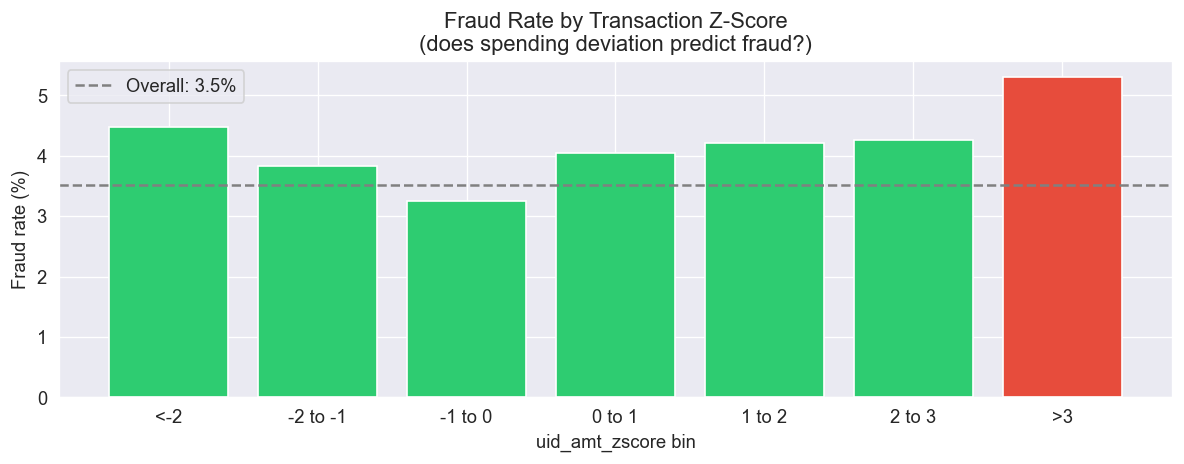

Saved: reports/zscore_fraud_rate.png


In [13]:
bins = [-np.inf, -2, -1, 0, 1, 2, 3, np.inf]
labels = ['<-2', '-2 to -1', '-1 to 0', '0 to 1', '1 to 2', '2 to 3', '>3']

split_train['zscore_bin'] = pd.cut(split_train['uid_amt_zscore'], bins=bins, labels=labels)

zscore_fraud = (split_train.groupby('zscore_bin', observed=True)['isFraud']
                .agg(['mean', 'count'])
                .rename(columns={'mean': 'fraud_rate', 'count': 'n_transactions'}))
zscore_fraud['fraud_rate_pct'] = (zscore_fraud['fraud_rate'] * 100).round(2)

print('Fraud rate by Z-score bin (split_train):')
print(zscore_fraud.to_string())

split_train = split_train.drop(columns=['zscore_bin'])

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(zscore_fraud.index, zscore_fraud['fraud_rate_pct'],
              color=['#2ecc71' if v < 5 else '#e74c3c' for v in zscore_fraud['fraud_rate_pct']],
              edgecolor='white')
ax.axhline(split_train['isFraud'].mean() * 100, color='gray', linestyle='--',
           label=f'Overall: {split_train["isFraud"].mean():.1%}')
ax.set_xlabel('uid_amt_zscore bin')
ax.set_ylabel('Fraud rate (%)')
ax.set_title('Fraud Rate by Transaction Z-Score\n(does spending deviation predict fraud?)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/zscore_fraud_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/zscore_fraud_rate.png')

## Email Domain Match

Fraudsters often reuse the same disposable email for both purchaser and
recipient fields.


In [14]:
# email_match was already created in Notebook 02 -- this cell just validates
# it here for reference, computed on split_train only
if 'P_emaildomain' in split_train.columns and 'R_emaildomain' in split_train.columns:
    if 'email_match' not in split_train.columns:
        for df in [split_train, split_test]:
            df['email_match'] = (df['P_emaildomain'] == df['R_emaildomain']).astype(np.int8)

    match_fraud_rate    = split_train[split_train['email_match'] == 1]['isFraud'].mean()
    mismatch_fraud_rate = split_train[split_train['email_match'] == 0]['isFraud'].mean()
    overall_fraud_rate  = split_train['isFraud'].mean()

    print(f'Email Domain Match Analysis (split_train):')
    print(f'  Overall fraud rate:              {overall_fraud_rate:.2%}')
    print(f'  Fraud rate when emails MATCH:    {match_fraud_rate:.2%}')
    print(f'  Fraud rate when emails MISMATCH: {mismatch_fraud_rate:.2%}')
    mult = match_fraud_rate / overall_fraud_rate if overall_fraud_rate > 0 else 0
    print(f'  -> Email match is {mult:.1f}x more likely to be fraud than average')
else:
    print('P_emaildomain / R_emaildomain columns not found -- check column names.')

Email Domain Match Analysis (split_train):
  Overall fraud rate:              3.51%
  Fraud rate when emails MATCH:    9.29%
  Fraud rate when emails MISMATCH: 2.23%
  -> Email match is 2.6x more likely to be fraud than average


## Frequency Encoding

Replaces raw categorical IDs with their occurrence count in the training
set. Generalizes to unseen cards in the test set (frequency 0 is itself
informative) without memorizing specific IDs.


In [15]:
freq_encode_cols = ['card1', 'card2', 'card3', 'card5', 'addr1', 'addr2',
                    'P_emaildomain', 'R_emaildomain']
freq_encode_cols = [c for c in freq_encode_cols if c in split_train.columns]

print('Applying frequency encoding (counts learned from split_train only)...')
for col in freq_encode_cols:
    # Frequency counts learned exclusively from split_train
    freq_map = split_train[col].value_counts()
    new_col  = f'{col}_freq'

    split_train[new_col] = split_train[col].map(freq_map).fillna(0).astype(np.int32)

    # Apply the SAME train-derived counts to split_test. A category value
    # seen in test but never in train naturally gets fillna(0) -- which
    # correctly represents "this card/address was never seen during training",
    # itself a meaningful signal (very low/zero frequency = suspicious/new).
    split_test[new_col] = split_test[col].map(freq_map).fillna(0).astype(np.int32)

    n_unseen_test = (split_test[col].map(freq_map).isna()).sum()
    print(f'  {col:20s} -> {new_col:25s}  (train unique values: {freq_map.shape[0]:,}, '
          f'unseen in test: {n_unseen_test:,})')

print(f'\nFrequency encoding complete. New columns: {[c + "_freq" for c in freq_encode_cols]}')

Applying frequency encoding (counts learned from split_train only)...
  card1                -> card1_freq                 (train unique values: 12,730, unseen in test: 1,293)
  card2                -> card2_freq                 (train unique values: 500, unseen in test: 1,908)
  card3                -> card3_freq                 (train unique values: 106, unseen in test: 758)
  card5                -> card5_freq                 (train unique values: 113, unseen in test: 1,128)
  addr1                -> addr1_freq                 (train unique values: 328, unseen in test: 11,952)
  addr2                -> addr2_freq                 (train unique values: 70, unseen in test: 11,953)
  P_emaildomain        -> P_emaildomain_freq         (train unique values: 59, unseen in test: 20,870)
  R_emaildomain        -> R_emaildomain_freq         (train unique values: 60, unseen in test: 94,437)

Frequency encoding complete. New columns: ['card1_freq', 'card2_freq', 'card3_freq', 'card5_freq', 'add

Fraud rate by card1 frequency (split_train):
                fraud_rate  n_transactions  fraud_rate_pct
card1_freq_bin                                            
1                 0.038462            3380            3.85
2-5               0.027727           12695            2.77
6-20              0.023739           33152            2.37
21-100            0.029159           66361            2.92
101-500           0.036110           92689            3.61
500+              0.038038          264155            3.80


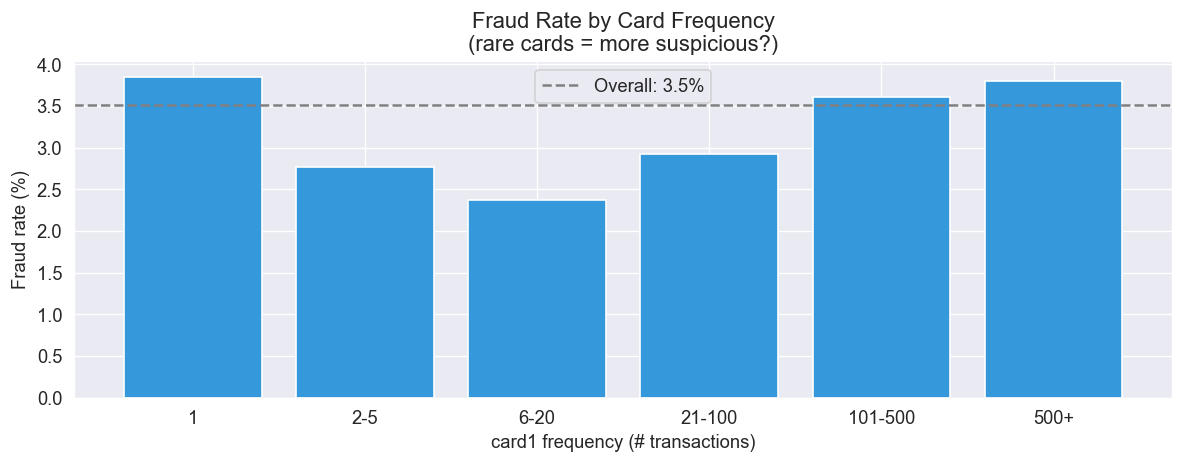

Saved: reports/card_freq_fraud_rate.png


In [16]:
bins = [0, 1, 5, 20, 100, 500, np.inf]
labels = ['1', '2-5', '6-20', '21-100', '101-500', '500+']

split_train['card1_freq_bin'] = pd.cut(split_train['card1_freq'], bins=bins, labels=labels)

freq_fraud = (split_train.groupby('card1_freq_bin', observed=True)['isFraud']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'fraud_rate', 'count': 'n_transactions'}))
freq_fraud['fraud_rate_pct'] = (freq_fraud['fraud_rate'] * 100).round(2)

print('Fraud rate by card1 frequency (split_train):')
print(freq_fraud.to_string())

split_train = split_train.drop(columns=['card1_freq_bin'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(freq_fraud.index, freq_fraud['fraud_rate_pct'],
       color='#3498db', edgecolor='white')
ax.axhline(split_train['isFraud'].mean() * 100, color='gray', linestyle='--',
           label=f'Overall: {split_train["isFraud"].mean():.1%}')
ax.set_xlabel('card1 frequency (# transactions)')
ax.set_ylabel('Fraud rate (%)')
ax.set_title('Fraud Rate by Card Frequency\n(rare cards = more suspicious?)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/card_freq_fraud_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/card_freq_fraud_rate.png')

## Time Encoding

Sin/cos transform so cyclical boundaries (hour 23 / hour 0) are treated as
neighbors instead of being numerically far apart.


Time features created: hour, dayofweek, hour_sin, hour_cos, dayofweek_sin, dayofweek_cos


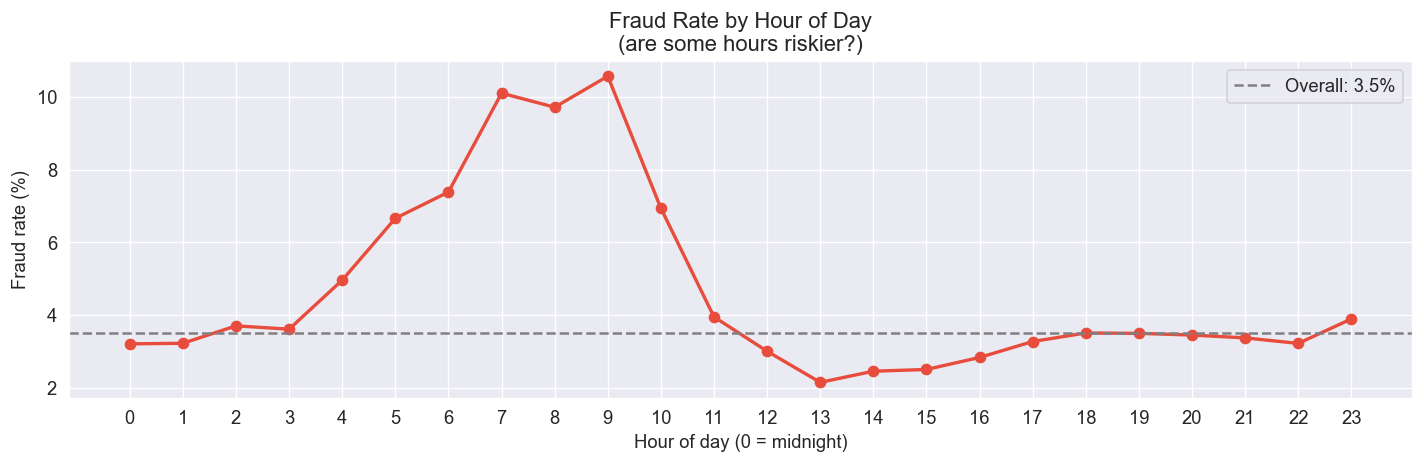

Saved: reports/hour_fraud_rate.png


In [17]:
# Feature creation -- pure arithmetic, no leakage risk, applied to both
for df in [split_train, split_test]:
    df['hour']      = ((df['TransactionDT'] // 3600) % 24).astype(np.int8)
    df['dayofweek'] = ((df['TransactionDT'] // 86400) % 7).astype(np.int8)
    df['hour_sin']      = np.sin(2 * np.pi * df['hour'] / 24).astype(np.float32)
    df['hour_cos']      = np.cos(2 * np.pi * df['hour'] / 24).astype(np.float32)
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7).astype(np.float32)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7).astype(np.float32)

print('Time features created: hour, dayofweek, hour_sin, hour_cos, dayofweek_sin, dayofweek_cos')

# Validation plot -- split_train only
hour_fraud = split_train.groupby('hour')['isFraud'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hour_fraud.index, hour_fraud.values * 100, marker='o', color='#e74c3c', linewidth=2)
ax.axhline(split_train['isFraud'].mean() * 100, color='gray', linestyle='--',
           label=f'Overall: {split_train["isFraud"].mean():.1%}')
ax.set_xlabel('Hour of day (0 = midnight)')
ax.set_ylabel('Fraud rate (%)')
ax.set_title('Fraud Rate by Hour of Day\n(are some hours riskier?)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig('../reports/hour_fraud_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/hour_fraud_rate.png')

## Cleanup and Save

UID and helper columns are dropped -- the model must never see raw
identifiers, only the aggregated statistics computed from them.


In [18]:
# Drop UID and helper columns before saving --
# CRITICAL: drop UID itself, the model must not memorize specific card/address
# combinations (67.4% of split_test UIDs were never seen in split_train, per
# Notebook 03's earlier check)

cols_to_drop = ['UID', 'D1_filled', 'TransactionDay']

for df_name, df in [('split_train', split_train), ('split_test', split_test)]:
    existing_drop = [c for c in cols_to_drop if c in df.columns]
    df.drop(columns=existing_drop, inplace=True)
    print(f'{df_name}: dropped {existing_drop}')

print(f'\nsplit_train shape: {split_train.shape}')
print(f'split_test shape:  {split_test.shape}')
print(f'Memory (split_train): {split_train.memory_usage().sum() / 1024**2:.1f} MB')
print(f'Fraud rate (split_train): {split_train["isFraud"].mean():.2%}')
print(f'Fraud rate (split_test):  {split_test["isFraud"].mean():.2%}')

new_features = [
    'uid_amt_mean', 'uid_amt_std', 'uid_amt_zscore', 'uid_count', 'uid_freq_per_day',
    'email_match',
    'card1_freq', 'card2_freq', 'card3_freq', 'card5_freq',
    'addr1_freq', 'addr2_freq', 'P_emaildomain_freq', 'R_emaildomain_freq',
    'hour', 'dayofweek', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos',
    'D1n'
]
existing = [f for f in new_features if f in split_train.columns]
print(f'\nNew features in dataset ({len(existing)} total):')
for f in existing:
    print(f'  {f}')

split_train: dropped ['UID', 'D1_filled', 'TransactionDay']
split_test: dropped ['UID', 'D1_filled', 'TransactionDay']

split_train shape: (472432, 374)
split_test shape:  (118108, 374)
Memory (split_train): 423.5 MB
Fraud rate (split_train): 3.51%
Fraud rate (split_test):  3.44%

New features in dataset (21 total):
  uid_amt_mean
  uid_amt_std
  uid_amt_zscore
  uid_count
  uid_freq_per_day
  email_match
  card1_freq
  card2_freq
  card3_freq
  card5_freq
  addr1_freq
  addr2_freq
  P_emaildomain_freq
  R_emaildomain_freq
  hour
  dayofweek
  hour_sin
  hour_cos
  dayofweek_sin
  dayofweek_cos
  D1n


In [20]:
split_train.to_parquet('../data/split_train_engineered.parquet', index=False)
split_test.to_parquet('../data/split_test_engineered.parquet', index=False)

print(f'Saved: ../data/split_train_engineered.parquet  {split_train.shape}')
print(f'Saved: ../data/split_test_engineered.parquet   {split_test.shape}')

Saved: ../data/split_train_engineered.parquet  (472432, 374)
Saved: ../data/split_test_engineered.parquet   (118108, 374)
